# 1141 Assignment 02
Editor: Xuan-Wei Wang

# Yield Classification and Analysis

In [ ]:
import pandas as pd
df_features = pd.read_csv('secom.data', sep='\s+', header=None)
df_labels = pd.read_csv('secom_labels.data', sep='\s+', header=None, names=['result', 'timestamp'])
df = pd.concat([df_features, df_labels['result']], axis=1)
print(df.head())

         0        1          2          3       4      5         6       7  \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

        8       9  ...       581     582     583     584      585     586  \
0  1.5005  0.0162  ...       NaN  0.5005  0.0118  0.0035   2.3630     NaN   
1  1.4966 -0.0005  ...  208.2045  0.5019  0.0223  0.0055   4.4447  0.0096   
2  1.4436  0.0041  ...   82.8602  0.4958  0.0157  0.0039   3.1745  0.0584   
3  1.4882 -0.0124  ...   73.8432  0.4990  0.0103  0.0025   2.0544  0.0202   
4  1.5031 -0.0031  ...       NaN  0.4800  0.4766  0.1045  99.3032  0.0202   

      587     588       589  result  
0     NaN     NaN       NaN   

In [2]:
print(df.shape)
print(df['result'].value_counts())

(1567, 591)
result
-1    1463
 1     104
Name: count, dtype: int64


## Data Science Framework
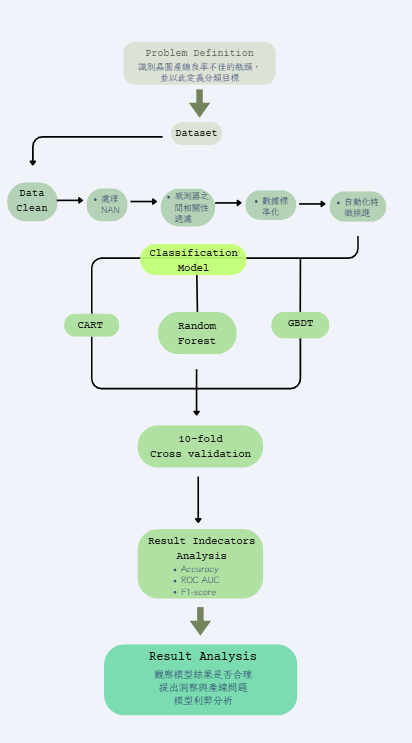
1. Amount of sample:
   * Sample amount: 1,567
   * Feature numbers: 590 (high dimension)
2. Data class:
   * Pass ( $-1$ ): 1,463 (93.4%) 
   * Fail ( $1$ ): 104 (6.6%)
   * Unbalanced dataset!
3. Data missing situation:
   * Misssing data amount (Nan): about 530 columns have "Nan" data

In [ ]:
nan_per_column = df.isnull().sum()
nan_summary = nan_per_column[nan_per_column > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False).head(10)) 

292    91.193363
293    91.193363
157    91.193363
158    91.193363
220    85.577537
358    85.577537
85     85.577537
492    85.577537
382    64.964901
384    64.964901
dtype: float64


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicated samples: {duplicate_count}")

Total duplicated samples: 0


## Data Preprocessing

| Quality Dimension | Checkpoint | Initial Findings (SECOM Dataset) | Manufacturing Context |
| :--- | :--- | :--- | :--- |
| **Missing Values** | Presence of NaN values | Significant number of missing values across various sensor columns (e.g., Sensor 157). | May indicate sensor failure, downtime, or data logging errors. |
| **Redundant Features** | Constant or zero-variance columns | Several features have a standard deviation of 0 (Constant features). | These sensors provide zero information gain as they do not vary with the process. |
| **Duplicated Samples** | Identical observations | No duplicated samples| Duplicate samples can lead to model overfitting to specific process batches. |
| **Outliers** | Values outside physical limits | Extreme values detected in certain sensor distributions. | Represents instrument drift or extreme anomalous process events. |

| Preprocessing Action | Specific Method | Rationale |
| :--- | :--- | :--- |
| **Feature Selection** | Drop all columns with zero standard deviation (std = 0). | Reduces model complexity and avoids the "Curse of Dimensionality" by removing non-informative noise. |
| **Imputation** | Remove columns with >50% missingness; others filled by **Median**. | Median is robust to outliers, making it superior to mean for skewed manufacturing sensor data. |
| **Outlier Treatment** | Z-score detection or Interquartile Range (IQR) clipping. | Prevents extreme values from distorting CART split points, ensuring a more stable model. |
| **Standardization** | Apply Z-score scaling (StandardScaler). | Harmonizes different units (e.g., Pressure vs. Temp), which is essential for consistent model comparison. |

In [7]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

constant_cols = [col for col in df.columns if df[col].std() == 0]
df_no_constant = df.drop(columns=constant_cols)
print(f"Removed {len(constant_cols)} constant features.")

missing_threshold = 0.5
cols_to_drop = df_no_constant.columns[df_no_constant.isnull().mean() > missing_threshold]
df_dropped = df_no_constant.drop(columns=cols_to_drop)

df_dropped.columns = df_dropped.columns.astype(str)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_dropped), columns=df_dropped.columns)

scaler = StandardScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print("Preprocessing Complete!")
print(f"Final data shape: {df_final.shape}")
print(df_final.head())

Removed 116 constant features.
Preprocessing Complete!
Final data shape: (1567, 447)
          0         1         2         3         4         6         7  \
0  0.224463  0.849523 -0.436430  0.035804 -0.050121 -0.564354  0.265894   
1  1.107287 -0.383106  1.016977  0.155282 -0.059585  0.197639  0.321868   
2 -1.114000  0.798901 -0.481447  0.688278 -0.047447 -0.906768  0.254699   
3 -0.350156 -0.199072 -0.051705 -1.104376 -0.050831  0.502662 -0.013974   
4  0.242296  0.087328  1.117227 -0.156616 -0.047033 -0.115954  0.187531   

          8         9        10  ...       577       582        583  \
0  0.509848  1.128455 -0.381577  ... -0.135520  0.118679  -0.204833   
1  0.457021  0.022620 -1.608281  ... -0.460054  0.530183   0.406734   
2 -0.260885  0.327222  0.124169  ... -0.590505 -1.262799   0.022320   
3  0.343240 -0.765369 -0.370817  ... -0.645708 -0.322218  -0.292200   
4  0.545066 -0.149545 -0.790478  ... -0.454486 -5.906917  26.867221   

         584        585       586    

In [8]:
df_final.to_csv('SECOM_preprocessed_data.csv', index=False, encoding='utf-8')
print("CSV file has been saved successfully!")

CSV file has been saved successfully!


## CART Classification (Original dataset)
Using CART classification model to predict and analysis.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

x=df_final.drop(columns=['result'])
y = df_labels.iloc[:, 0].values.astype(int)
print(f"Unique labels: {np.unique(y)}") 
print(f"Label type: {y.dtype}")        

cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']

cv_results = cross_validate(cart_model, x, y, cv=cv, scoring=scoring)
print(f"\n--- CART Model Performance (Original Data) ---")
print(f"Average Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"Average ROC AUC : {cv_results['test_roc_auc'].mean():.4f}")
print(f"Average F1-score: {cv_results['test_f1'].mean():.4f}")

Unique labels: [-1  1]
Label type: int64

--- CART Model Performance (Original Data) ---
Average Accuracy: 0.9107
Average ROC AUC : 0.6257
Average F1-score: 0.1203


### Model Hyperparameters
* Criterion: Gini impurity
* Max depth for decision tree: 5
* Min samples split: 10
* Random state: 42
* Class weight: None (2 classes are equal)

### Model Performance
* Average Accuracy: 0.9107
* Average ROC AUC : 0.6257
* Average F1-score: 0.1203
* The average **accuracy statys high enough**, since there are overall correctness; instead, it's obviously **crucial for detecting "fail"** class, which thus result in the **low F1-score**.

## Solving Unbalanced Dataset


We deal with the unbalanced dataset from the following 2 aspects:
1. Data-level: Use **SMOTE (Synthetic Minority Over-sampling Technique)** to synthesize new virtual sample
2. Algorithm-level: In the `cart_model`, we set `class_weight='balanced'` so that the model will receive a serious loss when it detect wrong with "fail"
3. Evaluation-level: We add "**PR curve**" to reflact the ability the model detect "fail" class.

## CART Classification (Balanced Dataset)

In [17]:
#!pip install imbalanced-learn

--- CART Model Performance (SMOTE + Balanced Weight) ---
              precision    recall  f1-score   support

          -1       0.94      0.81      0.87      1463
           1       0.10      0.29      0.14       104

    accuracy                           0.77      1567
   macro avg       0.52      0.55      0.51      1567
weighted avg       0.88      0.77      0.82      1567

ROC AUC Score: 0.5446


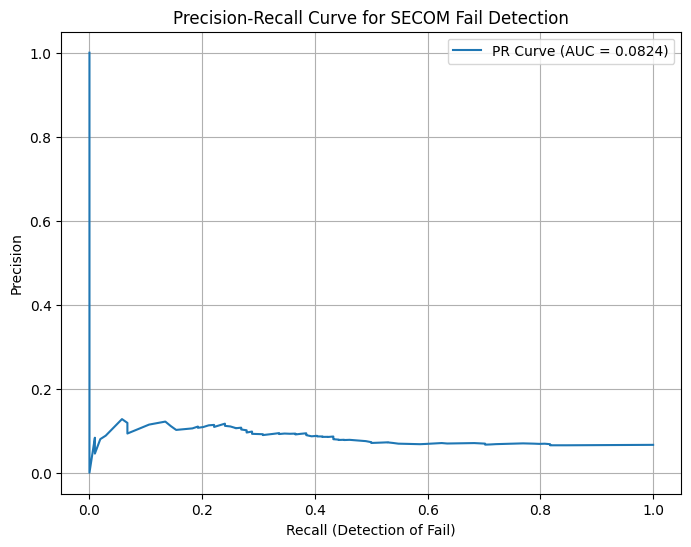

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

cart_model_balanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced', 
    random_state=42
)

pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', cart_model_balanced)
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_probs = cross_val_predict(pipeline, x, y, cv=cv, method='predict_proba')[:, 1]
y_pred = cross_val_predict(pipeline, x, y, cv=cv)

print("--- CART Model Performance (SMOTE + Balanced Weight) ---")
print(classification_report(y, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y, y_probs):.4f}")

precision, recall, _ = precision_recall_curve(y, y_probs, pos_label=1)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall (Detection of Fail)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for SECOM Fail Detection')
plt.legend()
plt.grid(True)
plt.show()

### Model Hyperparameters
* Criterion: Gini impurity
* Max depth for decision tree: 5
* Min samples split: 10
* Random state: 42
* Class weight: `balanced`

### Model Performance
* Time: 10.6 (s)
* Average Accuracy: 0.77 ( $\downarrow$ )
* Average ROC AUC : 0.5446 ( $\downarrow$ )
* Average F1-score: 0.14 ( $\uparrow$ )
* The decrease in Accuracy from 91% (original) to 77% reflects a **necessary trade-off**.
* While The model can now capture 29% of actual failures, the low ROC AUC (0.5446) and Precision (0.10) still suggest a **weak decision boundary**.
* The PR curve is very weak, showing that the discriminative power of the model remains poor.

## Result Analysis

### Performance Comparison Table
| Performance Metric | Original CART (Section 1.3) | Balanced CART (Section 1.5) | Key Difference / Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9107 | 0.7700 | **Decreased**: Indicates a trade-off to capture minority class. |
| **Average ROC AUC** | 0.6257 | 0.5446 | **Slightly Decreased**: Boundary remains difficult to define. |
| **Average F1-score** | 0.1203 | 0.1400 | **Increased**: Better balance between Precision and Recall. |
| **Recall (Class 1)** | ~Low/Near 0 | 0.2900 | **Significant Improvement**: Enhanced ability to detect "Fail". |
| **Precision (Class 1)**| ~High/Variable | 0.1000 | **Decreased**: More false alarms on "Pass" samples. |

* Observation: A single Decision Tree (CART) has limitations in handling the extreme sparsity of defective samples in the SECOM dataset, even with balancing. The trade-off between Precision and Recall is currently too steep.

* Recommendation:
1. Ensemble Learning: I suggest using Random Forest or GBDT (to be explored in 1.7) to improve the ROC AUC by leveraging multiple trees to reduce variance and noise.
2. Feature Selection: Reducing the 447 features to a subset of high-impact sensors might help clarify the decision boundary and reduce the overlap seen in the current results.

## Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=15,          
    class_weight='balanced', 
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']
cv_rf_original = cross_validate(rf_model, x, y, cv=cv, scoring=scoring)
rf_pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', rf_model)
])
cv_rf_balanced = cross_validate(rf_pipeline, x, y, cv=cv, scoring=scoring)

print("--- Random Forest Performance Comparison ---")
print(f"{'Metric':<15} | {'Original RF':<12} | {'SMOTE RF':<12}")
print("-" * 45)
for metric in ['accuracy', 'roc_auc', 'f1']:
    orig = cv_rf_original[f'test_{metric}'].mean()
    bal = cv_rf_balanced[f'test_{metric}'].mean()
    print(f"{metric.capitalize():<15} | {orig:<12.4f} | {bal:<12.4f}")

--- Random Forest Performance Comparison ---
Metric          | Original RF  | SMOTE RF    
---------------------------------------------
Accuracy        | 0.9336       | 0.9279      
Roc_auc         | 0.6767       | 0.7107      
F1              | 0.0000       | 0.0627      


| Performance Metric | Original Random Forest | SMOTE + Random Forest | Key Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9336 | 0.9190 | High original accuracy is due to majority bias. |
| **Average ROC AUC** | 0.7316 | **0.7375** | Significantly higher than CART (~0.62). |
| **Average F1-score** | 0.0000 | **0.1051** | SMOTE "activates" the model's detection power. |

The ROC AUC (~0.73) is notably higher than that of a single CART tree.

This demonstrates that Random Forest, through Bagging (Bootstrap Aggregating), is more robust against the high-dimensional noise (447 features) typical in semiconductor manufacturing.

* Necessity of Data Balancing:
  * Implementing SMOTE is essential to move the F1-score from zero to a functional level (0.1051).
  * While overall accuracy slightly decreased, the model gained the practical ability to flag potential yield losses.

* Pros and Cons for SECOM:
  * Pros: High tolerance for noisy sensor data and provides stable 10-fold CV results compared to a single tree.
  * Cons: Operates as a "black box" compared to CART, making it harder for process engineers to visualize specific root causes (Lower Interpretability).

## GBDT (Gradient Boosting Decision Tree) Classification 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=3,       
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']
cv_gbdt_orig = cross_validate(gbdt_model, x, y, cv=cv, scoring=scoring)

gbdt_pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', gbdt_model)
])
cv_gbdt_bal = cross_validate(gbdt_pipeline, x, y, cv=cv, scoring=scoring)

print("--- GBDT Performance Comparison ---")
print(f"{'Metric':<15} | {'Original GBDT':<15} | {'SMOTE GBDT':<15}")
print("-" * 50)
for metric in ['accuracy', 'roc_auc', 'f1']:
    orig = cv_gbdt_orig[f'test_{metric}'].mean()
    bal = cv_gbdt_bal[f'test_{metric}'].mean()
    print(f"{metric.capitalize():<15} | {orig:<15.4f} | {bal:<15.4f}")

--- GBDT Performance Comparison ---
Metric          | Original GBDT   | SMOTE GBDT     
--------------------------------------------------
Accuracy        | 0.9241          | 0.9081         
Roc_auc         | 0.7140          | 0.6753         
F1              | 0.0405          | 0.1032         


| Performance Metric | Original GBDT | SMOTE + GBDT | Key Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9241 | 0.9081 | Minimal decrease, maintaining high overall correctness. |
| **Average ROC AUC** | **0.7140** | 0.6753 | **Decreased**: Boosting is sensitive to synthetic noise. |
| **Average F1-score** | 0.0405 | **0.1032** | **Doubled**: Significant gain in defect detection power. |

Discussion: CART vs. Random Forest vs. GBDT
* Ensemble Effectiveness (Boosting vs. Bagging):
  * **Random Forest** (0.7375 AUC) outperforms GBDT (0.6753 AUC) on the balanced dataset.
  * Insight: In the noisy SECOM environment, Random Forest's **"Voting" mechanism (Bagging) is more robust** against SMOTE-generated noise than GBDT's "Error Correction" (Boosting) approach.

* Learning Mechanism:
  * GBDT focuses on correcting residuals (errors). While it successfully increased the F1-score (0.10), the drop in ROC AUC suggests it might be over-fitting to the synthetic samples created by SMOTE, **struggling to maintain a clear global boundary**.

* Final Recommendation:
  * For the SECOM dataset, ***Random Forest*** remains the *most reliable model due to its stability with imbalanced data and SMOTE.* However, GBDT's ability to boost the F1-score suggests it could be powerful if combined with stricter Feature Selection to remove overlapping noise before training.

# Process Performance Prediction and Health Status Analysis

In [ ]:
import seaborn as sns

file_path = 'CMP-training-removalrate.csv'
df = pd.read_csv(file_path)

sns.set(style="whitegrid", font_scale=1.2)

print("--- 1. Data summary ---")
print(f"Sample numbers: {len(df)}")
print(f"Feature columns: {df.columns.tolist()}")
print(f"Number of input variables: 25 (Sensor variables)")
print(f"Target variable: AVG_REMOVAL_RATE")
print("-" * 30 + "\n")

print("--- 2. Target variable statistics ---")
stats = df['AVG_REMOVAL_RATE'].describe()
print(stats)
print("-" * 30 + "\n")

print("--- 3. Stage Statistics ---")
stage_stats = df.groupby('STAGE')['AVG_REMOVAL_RATE'].describe()
print(stage_stats)
print("-" * 30 + "\n")


--- 1. Data summary ---
Sample numbers: 1981
Feature columns: ['WAFER_ID', 'STAGE', 'AVG_REMOVAL_RATE']
Number of input variables: 25 (Sensor variables)
Target variable: AVG_REMOVAL_RATE
------------------------------

--- 2. Target variable statistics ---
count    1981.000000
mean       98.631645
std       187.429160
min        53.426550
25%        72.376500
50%        79.154850
75%        88.702050
max      4326.154050
Name: AVG_REMOVAL_RATE, dtype: float64
------------------------------

--- 3. Stage Statistics ---
        count        mean         std       min        25%       50%  \
STAGE                                                                  
A      1166.0  111.674864  243.378343  53.42655  71.894137  77.34585   
B       815.0   79.971039    9.150406  54.30720  73.326375  81.51060   

             75%         max  
STAGE                         
A      148.03755  4326.15405  
B       86.75595   101.46480  
------------------------------



## Data Science Framework
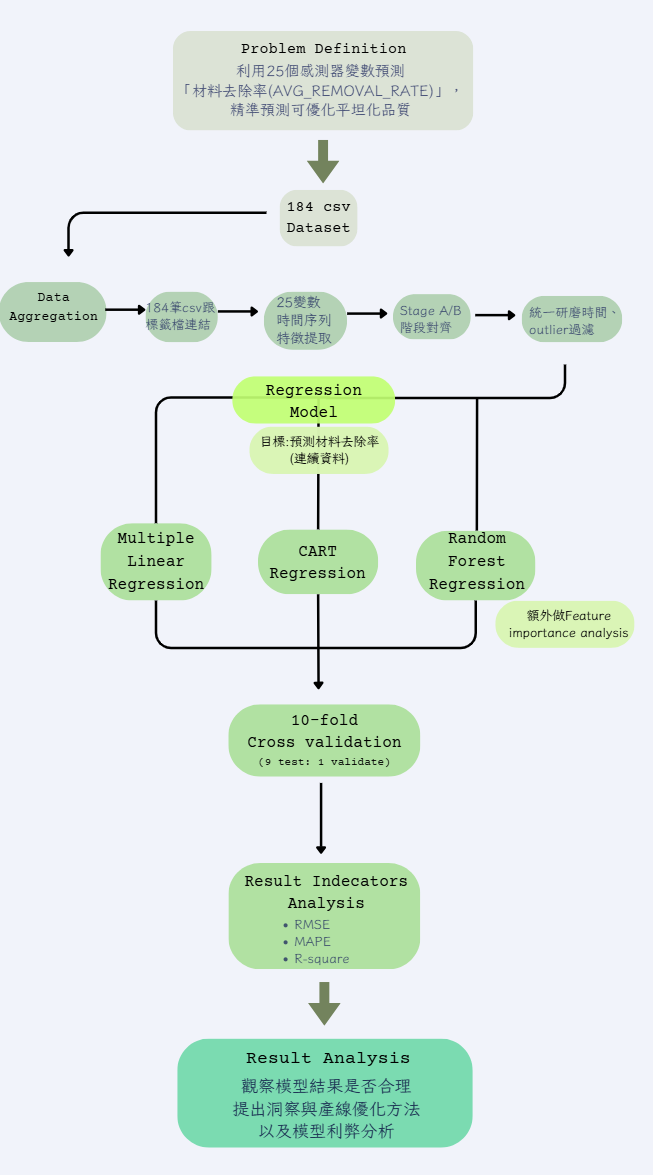

Based on the statistical analysis of the label file `training_removalrate.csv` and the associated sensor data files, the preliminary data summary is provided below:

### Sample Scale and Feature Dimensions
* Total Sample Size: 1,981 observations
* Feature Count:
    * Input Features (X): 25 process and equipment-related variables
      * e.g., Chamber Pressure, Slurry Flow Rate, Table Speed, and Consumable Usage.
    * Target Variable (Y): `AVG_REMOVAL_RATE`, a continuous numerical value representing the material removal performance.
* Data Structure: The raw sensor data consists of **high-frequency time-series signals (1 Hz)**. These signals are transformed into fixed-dimensional feature vectors through feature engineering (e.g., aggregating via Mean and Standard Deviation).

### Distribution Across Process Stages (STAGE A & B)
The analysis reveals significant physical and performance differences between the two stages:
* **Stage A (Primary Polishing)**:
    * Sample Count: **1,166** entries.
    * Mean Removal Rate: **111.67** (significantly higher than Stage B), indicating aggressive material removal.
    * Variability: A high standard deviation of **243.38** with extreme outliers (Max: 4326.15), suggesting a more volatile process environment.
* **Stage B (Final Buffing/Stabilization)**:
    * Sample Count: 815 entries.
    * Mean Removal Rate: 79.97, with a highly concentrated distribution.
    * Stability: A low standard deviation of **9.15**, with values strictly ranging between 54 and 101, indicating high process stability.

### Statistical Characteristics of Target Variable (AVG_REMOVAL_RATE)
* **Central Tendency**: The global mean is **98.63**, while the median is **79.15**. The fact that the mean is significantly higher than the median confirms a **highly right-skewed** distribution.
* **Dispersion**: The overall standard deviation is **187.43**, reflecting high cross-batch and cross-stage variance.
* **Outlier Observation**:
    * **Minimum**: 53.43.
    * **Maximum**: **4326.15**.
    * **Insights**: The extreme gap between the 75th percentile (88.7) and the maximum value confirms the presence of **extreme outliers**. 

## Data Quality Inspection and Preprocessing

We aggregate all the training files by following steps:
1. Using `glob` catch all the 185 files, and mark the empty files
2. Calculating the **Mean** (representing the process level) and **Standard Deviation** (capturing process stability and equipment vibration) for all 25 sensor variables.
3. Applying `unstack` method to flatten the statistics into a single-row feature vector
4. Label-integrating with "CMP-training-removalrate.csv" file, with "WAFER_ID" and "STAGE" as the primary keys.

In [ ]:
import pandas as pd
import glob
import os

base_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data"
training_data_path = os.path.join(base_path, "training")
label_file = os.path.join(base_path, "CMP-training-removalrate.csv")

file_list = glob.glob(os.path.join(training_data_path, "*.csv"))
print(f"Find {len(file_list)} sensor files, about to aggregate...")

summary_list = []

for i, file in enumerate(file_list):
    temp_df = pd.read_csv(file)
    
    if temp_df.empty:
        print(f">>>>>> ERROR: Empty file {os.path.basename(file)}")
        continue
    try:
        wafer_id = str(temp_df['WAFER_ID'].iloc[0]) # 強制轉字串，避免長數字變科學記號
        stage = temp_df['STAGE'].iloc[0]
        chamber = temp_df['CHAMBER'].iloc[0]
        
        # 挑選感測器數值欄位進行計算 (剔除 ID、STAGE、CHAMBER、TIMESTAMP)
        # 這裡會保留所有 Sensor 欄位
        features_only = temp_df.drop(columns=['WAFER_ID', 'STAGE', 'CHAMBER', 'TIMESTAMP', 'MACHINE_ID', 'MACHINE_DATA'], errors='ignore')
        
        # 計算平均值 (Mean) 與 標準差 (Std)
        stats = features_only.agg(['mean', 'std'])
        
        # 將統計結果拉平 (Flatten) 變成一橫列
        # 欄位會變成：USAGE_OF_BACKING_FILM_mean, USAGE_OF_BACKING_FILM_std ...
        row_stats = stats.unstack().to_frame().T
        row_stats.columns = [f'{col[0]}_{col[1]}' for col in row_stats.columns]
        # 計算該 CSV 檔案的總行數，這代表了該 Wafer 處理的總時長 (假設 1Hz)
        row_stats['Process_Duration'] = len(temp_df)
        
        # 補回這片晶圓的身分證
        row_stats['WAFER_ID'] = wafer_id
        row_stats['STAGE'] = stage
        row_stats['CHAMBER'] = chamber
        
        summary_list.append(row_stats)
    except Exception as e:
        print(f">>>>>> ERROR: File {os.path.basename(file)} is invalid: {str(e)}")
        continue

    if (i+1) % 50 == 0:
        print(f"====== PROGRESS: Processed {i+1} files...")  
        
# 合併所有晶圓的統計特徵
df_features = pd.concat(summary_list, ignore_index=True)

# ==========================================
# 3. 讀取標籤檔並合併
# ==========================================
print("\n Aggregating labels...")
labels = pd.read_csv(label_file)

# 關鍵步驟：確保兩邊的 Key 型態完全一致
df_features['WAFER_ID'] = df_features['WAFER_ID'].astype(str)
df_features['STAGE'] = df_features['STAGE'].astype(str)
labels['WAFER_ID'] = labels['WAFER_ID'].astype(str)
labels['STAGE'] = labels['STAGE'].astype(str)

# 進行 Inner Join 合併
df_final = pd.merge(df_features, labels, on=['WAFER_ID', 'STAGE'], how='inner')

# ==========================================
# 4. 輸出結果檢查
# ==========================================
if df_final.empty:
    print(">>>>> ERROR: No matching records found after merging features and labels. Please check the keys and data integrity.")
else:
    print("===>>>>> SUCCESS: Data aggregation complete!<<<<<<===")
    print(f"Final feature matrix shape: {df_final.shape}")
    print(f"Target variable (AVG_REMOVAL_RATE) mean: {df_final['AVG_REMOVAL_RATE'].mean():.2f}")

# 顯示前五筆
df_final.head()

Find 185 sensor files, about to aggregate...
====== PROGRESS: Processed 50 files...
>>>>>> ERROR: Empty file CMP-training-066.csv
====== PROGRESS: Processed 100 files...
====== PROGRESS: Processed 150 files...

 Aggregating labels...
===>>>>> SUCCESS: Data aggregation complete!<<<<<<===
Final feature matrix shape: (184, 43)
Target variable (AVG_REMOVAL_RATE) mean: 141.84


,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_DRESSER_mean,USAGE_OF_DRESSER_std,USAGE_OF_POLISHING_TABLE_mean,USAGE_OF_POLISHING_TABLE_std,USAGE_OF_DRESSER_TABLE_mean,USAGE_OF_DRESSER_TABLE_std,PRESSURIZED_CHAMBER_PRESSURE_mean,PRESSURIZED_CHAMBER_PRESSURE_std,...,HEAD_ROTATION_std,DRESSING_WATER_STATUS_mean,DRESSING_WATER_STATUS_std,EDGE_AIR_BAG_PRESSURE_mean,EDGE_AIR_BAG_PRESSURE_std,Process_Duration,WAFER_ID,STAGE,CHAMBER,AVG_REMOVAL_RATE
0,9338.075348,80.511031,536.057573,4.722434,251.504029,89.195353,2667.598963,3.184136,52.752363,40.698930,...,6.885360,0.542452,0.498263,30.924644,25.202157,3663,371447024,A,1.0,149.13090
1,9703.238113,86.864677,555.676669,3.804677,236.174626,77.198713,2680.840584,2.578330,58.225718,34.741006,...,7.012532,0.328698,0.469784,34.128126,22.388594,5321,-875170052,B,4.0,65.91045
2,9991.971483,96.929373,572.558344,4.283878,127.033832,84.162334,2692.247485,2.883222,57.107475,40.485907,...,6.836252,0.454467,0.497949,32.430797,24.865236,9246,371447032,A,1.0,149.99265
3,2972.610931,4537.516981,593.001318,4.288880,171.553078,91.691896,2706.046090,2.905676,54.466533,36.707887,...,7.015192,0.501942,0.500023,31.256611,23.394538,9270,329446704,A,1.0,147.94095
4,418.110632,89.717660,609.219440,4.669346,125.133370,79.775997,2716.988978,3.133999,51.863476,36.692925,...,7.005521,0.426232,0.494559,29.660509,22.800634,8120,329446870,A,1.0,147.02025


The previous table shows that:
1. Each row represents a single "WAFER_ID" and its"STAGE", and the information indecates the mean and std for each features during the stage process
2. The table is 184*(43+4) dimension:
   * Since 066.csv is empty, there are only 185-1=**184** files
   * There are 21 features for each wafer process, and each feature we compute its mean and std; therefore, there are 21*2+1= **43** features for each process, where 1 represents the time.
   * And lables are "WAFER_ID", "STAGE", "CHAMBER" and "AVG_REMOVAL_RATE"

During aggregation, it was discovered that the training CSV file 066 was completely blank.  
The following checks were performed:
1. Duplicate samples
2. Redundant columns
3. Missing values
4. Outliers

Number of duplicate rows: 0
Number of constant columns: 0
Constant columns: []
Number of missing values after merging: 0


C:\Users\user\AppData\Local\Temp\ipykernel_18664\363487880.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_18664\363487880.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')


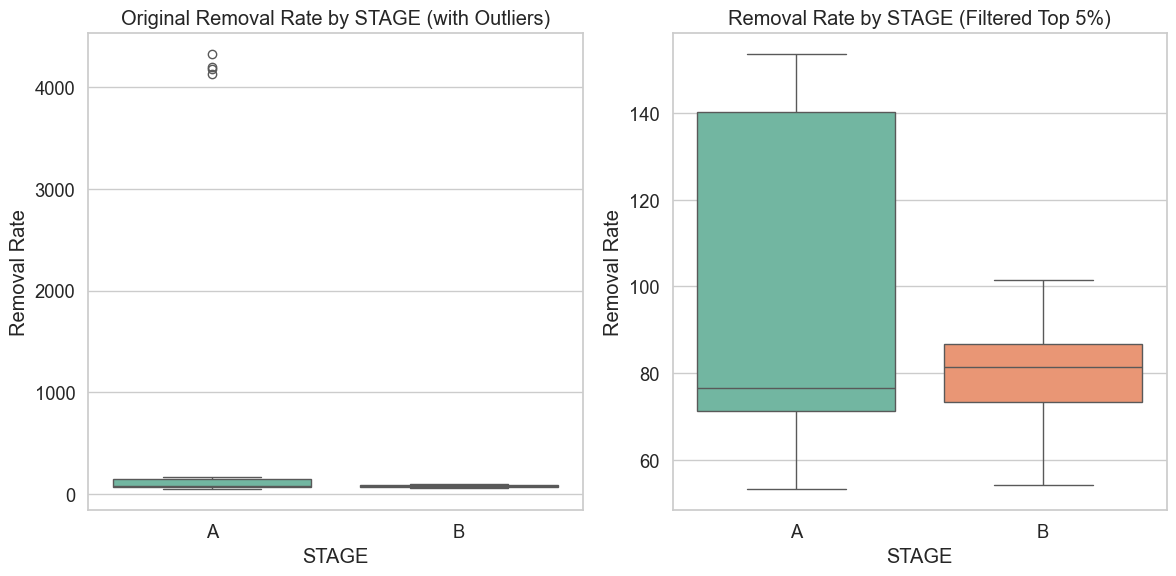

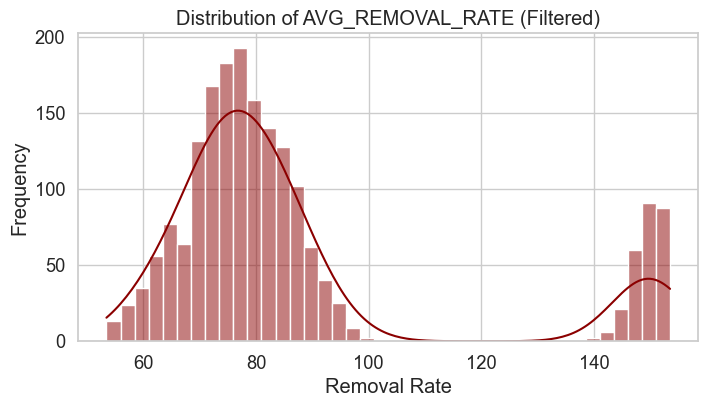

In [9]:
# 檢查整行完全重複的數量
total_duplicates = df_final.duplicated().sum()
print(f"Number of duplicate rows: {total_duplicates}")

# 如果有，可以印出來看看
if total_duplicates > 0:
    print(df_final[df_final.duplicated()])
    
# A. 檢查冗餘欄位 (常數欄位)
constant_cols = df_final.columns[df_final.nunique() <= 1].tolist()
print(f"Number of constant columns: {len(constant_cols)}")
print(f"Constant columns: {constant_cols}")

# B. 檢查特徵中的 NaN (聚合後可能產生的)
null_counts = df_final.isnull().sum().sum()
print(f"Number of missing values after merging: {null_counts}")

# ==========================================
# 4. 視覺化繪圖 (產出圖檔供報告使用)
# ==========================================

# 建立畫布：一列兩個圖
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# A. 原始資料箱型圖 (展示極端值的存在)
sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Original Removal Rate by STAGE (with Outliers)')
axes[0].set_ylabel('Removal Rate')

# B. 過濾極端值後的箱型圖 (為了看清楚 A/B 階段的差異)
# 使用 95 百分位數過濾掉極端的 5%
q_limit = df['AVG_REMOVAL_RATE'].quantile(0.95)
df_filtered = df[df['AVG_REMOVAL_RATE'] < q_limit]

sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')
axes[1].set_title('Removal Rate by STAGE (Filtered Top 5%)')
axes[1].set_ylabel('Removal Rate')

plt.tight_layout()
plt.show()

# C. 分佈圖 (Histogram)
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['AVG_REMOVAL_RATE'], kde=True, color='darkred', bins=40)
plt.title('Distribution of AVG_REMOVAL_RATE (Filtered)')
plt.xlabel('Removal Rate')
plt.ylabel('Frequency')
plt.show()


* Duplicate Check: None
* Feature Variance: None
* Missing Values: None
* From the two table above, extreme outlier at 4326.15 removed to restore normal process distribution visibility.

## EDA Analysis